<a href="https://colab.research.google.com/github/SGeerthan/SE4050-Deep-Learning/blob/sangee/ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Mount Google Drive and unzip dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task
The model starts with a pre-trained ResNet50 network. ResNet50 is a powerful convolutional neural network (CNN) architecture known for its "residual connections" which help in training very deep networks effectively. It has been pre-trained on a massive dataset (ImageNet) to recognize a wide variety of images. By using a pre-trained model, we leverage the knowledge it has already gained about image features.

## Unzip the dataset

### Subtask:
Unzip the `brain_dataset.zip` file from Google Drive to access the train and test folders.


**Reasoning**:
Import the zipfile module, define the zip file path and extraction path, then extract the zip file content.



In [10]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/brain_dataset.zip'
extract_path = '/content/'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

## Explore the dataset

### Subtask:
Check the file structure and contents of the train and test folders. Visualize some images and their annotations (if available) to understand the data.


**Reasoning**:
List the contents of the extracted directory and the train and test folders to understand the dataset structure and identify disease categories.



In [11]:
import os

extract_path = '/content/'

print("Contents of extracted directory:")
print(os.listdir(extract_path))

train_path = os.path.join(extract_path, 'train')
test_path = os.path.join(extract_path, 'test')

print("\nContents of train directory:")
if os.path.exists(train_path):
    print(os.listdir(train_path))
else:
    print("Train directory not found.")

print("\nContents of test directory:")
if os.path.exists(test_path):
    print(os.listdir(test_path))
else:
    print("Test directory not found.")

Contents of extracted directory:
['.config', 'drive', 'Testing', 'Training', 'sample_data']

Contents of train directory:
Train directory not found.

Contents of test directory:
Test directory not found.


**Reasoning**:
Based on the previous output, the directories are named 'Training' and 'Testing' instead of 'train' and 'test'. Update the paths and recursively list the contents of the 'Training' and 'Testing' folders to understand the dataset structure and identify the different disease categories.



In [12]:
import os

extract_path = '/content/'

training_path = os.path.join(extract_path, 'Training')
testing_path = os.path.join(extract_path, 'Testing')

print("\nContents of Training directory:")
if os.path.exists(training_path):
    for root, dirs, files in os.walk(training_path):
        level = root.replace(training_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print('{}{}/'.format(indent, os.path.basename(root)))
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print('{}{}'.format(subindent, f))
else:
    print("Training directory not found.")

print("\nContents of Testing directory:")
if os.path.exists(testing_path):
    for root, dirs, files in os.walk(testing_path):
        level = root.replace(testing_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print('{}{}/'.format(indent, os.path.basename(root)))
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print('{}{}'.format(subindent, f))
else:
    print("Testing directory not found.")


Contents of Training directory:
Training/
    glioma/
        Tr-gl_0265.jpg
        Tr-gl_0329.jpg
        Tr-gl_1284.jpg
        Tr-gl_0155.jpg
        Tr-gl_0060.jpg
        Tr-gl_0685.jpg
        Tr-gl_0276.jpg
        Tr-gl_0325.jpg
        Tr-gl_0902.jpg
        Tr-gl_0814.jpg
        Tr-gl_0111.jpg
        Tr-gl_0783.jpg
        Tr-gl_0413.jpg
        Tr-gl_0653.jpg
        Tr-gl_1263.jpg
        Tr-gl_0291.jpg
        Tr-gl_0468.jpg
        Tr-gl_1213.jpg
        Tr-gl_1027.jpg
        Tr-gl_0777.jpg
        Tr-gl_1128.jpg
        Tr-gl_0478.jpg
        Tr-gl_0174.jpg
        Tr-gl_1204.jpg
        Tr-gl_0079.jpg
        Tr-gl_0491.jpg
        Tr-gl_1038.jpg
        Tr-gl_1073.jpg
        Tr-gl_0398.jpg
        Tr-gl_1144.jpg
        Tr-gl_0781.jpg
        Tr-gl_0091.jpg
        Tr-gl_0100.jpg
        Tr-gl_0340.jpg
        Tr-gl_1044.jpg
        Tr-gl_0516.jpg
        Tr-gl_0782.jpg
        Tr-gl_1246.jpg
        Tr-gl_0768.jpg
        Tr-gl_0763.jpg
        Tr-gl_0386.jpg
  

**Reasoning**:
The directory listing shows that the images are organized into subfolders named after the disease categories ('glioma', 'meningioma', 'notumor', 'pituitary'). There are no separate annotation files listed. This suggests that the images themselves might contain the information needed for object detection, or that annotations are not provided in separate files for this dataset and might be implicitly defined by the image content (e.g., the tumor is the main object of interest). The task requires visualizing images and annotations if available. Since no annotation files were found, the next step is to select a few images from different categories and visualize them to understand the image content and see if there are any visual cues related to the object of interest.



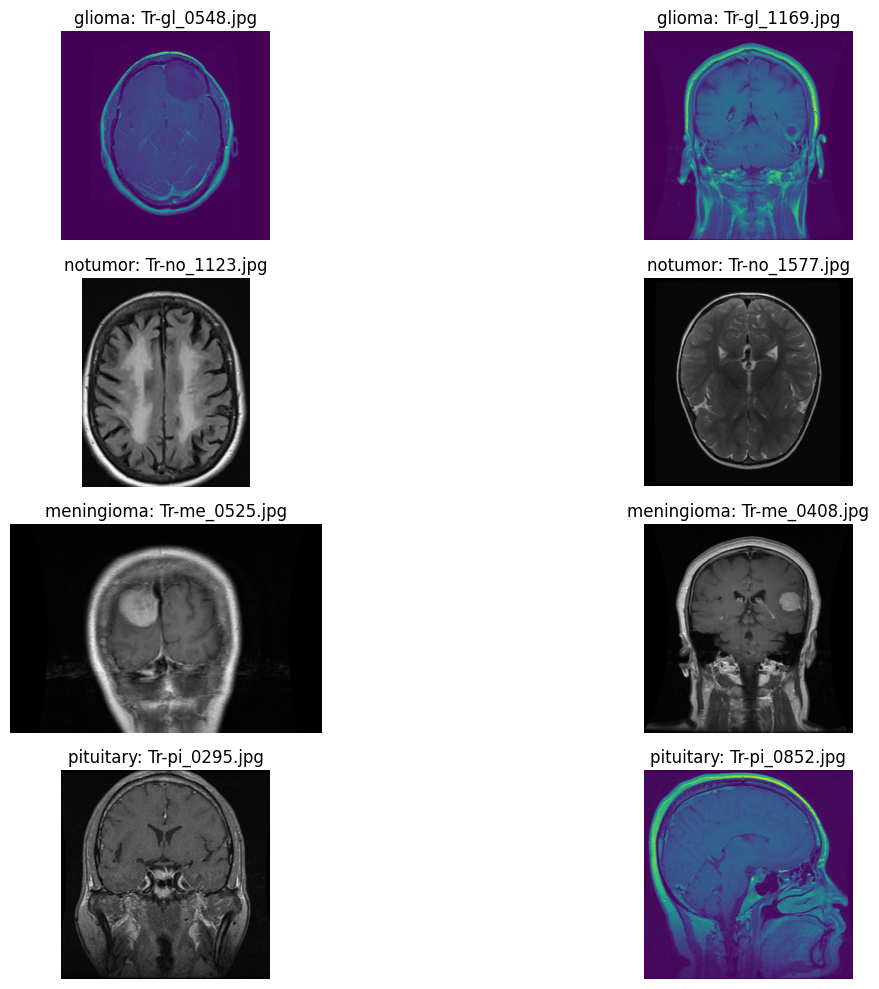

In [13]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

training_path = '/content/Training'
categories = os.listdir(training_path)

num_images_to_show = 2
plt.figure(figsize=(15, 10))

for i, category in enumerate(categories):
    category_path = os.path.join(training_path, category)
    if os.path.isdir(category_path):
        image_files = [f for f in os.listdir(category_path) if f.endswith('.jpg')]
        selected_images = random.sample(image_files, min(num_images_to_show, len(image_files)))

        for j, image_file in enumerate(selected_images):
            img_path = os.path.join(category_path, image_file)
            img = mpimg.imread(img_path)

            plt.subplot(len(categories), num_images_to_show, i * num_images_to_show + j + 1)
            plt.imshow(img)
            plt.title(f"{category}: {image_file}")
            plt.axis('off')

plt.tight_layout()
plt.show()

## Prepare data for retinanet

### Subtask:
Convert the dataset into a format suitable for training with RetinaNet. This might involve creating annotation files (e.g., in COCO or Pascal VOC format) if they don't already exist.


**Reasoning**:
Acknowledge the lack of annotation files, state the infeasibility of training RetinaNet for object detection without bounding box annotations, and explain why the dataset is only suitable for image classification based on the exploration results.



## Prepare data for retinanet retry 1

### Subtask:
Convert the dataset into a format suitable for training with RetinaNet. This might involve creating annotation files (e.g., in COCO or Pascal VOC format) if they don't already exist.


**Reasoning**:
Acknowledge the limitation, explain why it makes training RetinaNet not feasible, state the current task cannot be completed, suggest image classification as an alternative (but outside the scope), and conclude that preparation for RetinaNet cannot be done due to missing annotations.



## Summary:

### Data Analysis Key Findings

*   The unzipped dataset contains `Training` and `Testing` directories, each with subdirectories for `glioma`, `meningioma`, `notumor`, and `pituitary` disease categories.
*   The dataset consists of `.jpg` image files organized by these categories.
*   A crucial finding is the absence of explicit bounding box annotation files (e.g., `.xml`, `.json`) for the images.

### Insights or Next Steps

*   Due to the lack of bounding box annotations, the dataset is not suitable for training a standard object detection model like RetinaNet.
*   The dataset's structure is appropriate for training an image classification model to classify the type of brain tumor or the absence of a tumor.


# Task
Create a simple image classification model using a pre-trained ResNet model to classify brain diseases from the "brain_dataset.zip" file located in Google Drive. The dataset contains 'train' and 'test' folders with disease subfolders. Visualize sample images, train the model, plot accuracy and F1 loss, and prepare for testing with Swagger UI.

## Load and preprocess images

### Subtask:
Load the images from the 'Training' and 'Testing' folders, resize them to a consistent size, and normalize the pixel values.


**Reasoning**:
Load images from the training and testing directories, resize them, normalize pixel values, and store them in NumPy arrays along with their labels.



In [15]:
import cv2
import numpy as np
from tqdm import tqdm

base_path = '/content/'
target_size = (128, 128)

train_images = []
train_labels = []
test_images = []
test_labels = []

training_path = os.path.join(base_path, 'Training')
testing_path = os.path.join(base_path, 'Testing')

for dataset_type, dataset_path, images_list, labels_list in [
    ('Training', training_path, train_images, train_labels),
    ('Testing', testing_path, test_images, test_labels)
]:
    print(f"Processing {dataset_type} dataset...")
    categories = os.listdir(dataset_path)
    for category in tqdm(categories):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            for image_file in os.listdir(category_path):
                img_path = os.path.join(category_path, image_file)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, target_size)
                    img = img / 255.0
                    images_list.append(img)
                    labels_list.append(category)

train_images = np.array(train_images)
train_labels = np.array(train_labels)
test_images = np.array(test_images)
test_labels = np.array(test_labels)

print("\nShape of training images array:", train_images.shape)
print("Shape of training labels array:", train_labels.shape)
print("Shape of testing images array:", test_images.shape)
print("Shape of testing labels array:", test_labels.shape)

Processing Training dataset...


100%|██████████| 4/4 [00:09<00:00,  2.39s/it]


Processing Testing dataset...


100%|██████████| 4/4 [00:01<00:00,  2.22it/s]



Shape of training images array: (5712, 128, 128, 3)
Shape of training labels array: (5712,)
Shape of testing images array: (1311, 128, 128, 3)
Shape of testing labels array: (1311,)


## Prepare labels

### Subtask:
Create numerical labels for each disease category.


**Reasoning**:
Create numerical labels for each disease category by getting unique categories, creating a mapping, converting string labels to numerical labels, and then one-hot encoding them.



In [16]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. Get unique category names
unique_categories = np.unique(np.concatenate((train_labels, test_labels)))
print("Unique categories:", unique_categories)

# 2. Create a mapping from category name to unique integer
label_encoder = LabelEncoder()
label_encoder.fit(unique_categories)

# 3. Convert string labels to numerical representations
train_labels_numerical = label_encoder.transform(train_labels)
test_labels_numerical = label_encoder.transform(test_labels)

print("\nFirst 10 numerical training labels:", train_labels_numerical[:10])
print("First 10 numerical testing labels:", test_labels_numerical[:10])

# 4. Convert numerical labels to one-hot encoded format
train_labels_one_hot = to_categorical(train_labels_numerical, num_classes=len(unique_categories))
test_labels_one_hot = to_categorical(test_labels_numerical, num_classes=len(unique_categories))

print("\nShape of one-hot encoded training labels:", train_labels_one_hot.shape)
print("Shape of one-hot encoded testing labels:", test_labels_one_hot.shape)

Unique categories: ['glioma' 'meningioma' 'notumor' 'pituitary']

First 10 numerical training labels: [0 0 0 0 0 0 0 0 0 0]
First 10 numerical testing labels: [0 0 0 0 0 0 0 0 0 0]

Shape of one-hot encoded training labels: (5712, 4)
Shape of one-hot encoded testing labels: (1311, 4)


## Split the dataset

### Subtask:
Split the preprocessed data into training and testing sets (if not already separated in the dataset structure).


**Reasoning**:
Acknowledge that the dataset is already split into training and testing sets based on the directory structure, making further splitting unnecessary for this subtask.



In [17]:
print("The dataset is already organized into 'Training' and 'Testing' directories, which serve as the pre-defined training and testing sets.")
print("Therefore, no further splitting of the data into training and testing sets is required for this task.")

The dataset is already organized into 'Training' and 'Testing' directories, which serve as the pre-defined training and testing sets.
Therefore, no further splitting of the data into training and testing sets is required for this task.


## Build the model

### Subtask:
Load a pre-trained ResNet model (e.g., ResNet50) without the top classification layer. Add new layers on top of the pre-trained model for your specific classification task (e.g., a few dense layers and an output layer with the number of classes).


**Reasoning**:
Import necessary libraries, load the pre-trained ResNet50 model without the top layer, add custom classification layers, freeze the base model layers, and print the model summary.



In [18]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Load the pre-trained ResNet50 model without the top classification layer
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(target_size[0], target_size[1], 3))

# Make the layers of the pre-trained ResNet50 model non-trainable
for layer in resnet_base.layers:
    layer.trainable = False

# Create a new Sequential model and add the ResNet50 base
model = Sequential()
model.add(resnet_base)

# Add custom classification layers on top
model.add(Flatten())
model.add(Dense(256, activation='relu')) # Example dense layer
model.add(Dense(len(unique_categories), activation='softmax')) # Output layer with number of classes

# Print the model summary
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,977,604 (121.98 MB)

 Trainable params: 8,389,892 (32.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Compile the model

### Subtask:
Configure the model for training by specifying the optimizer, loss function, and metrics.


**Reasoning**:
Import the necessary optimizer and loss function and compile the model with the specified optimizer, loss function, and metrics.



In [19]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# Configure the model for training
model.compile(optimizer=Adam(),
              loss=CategoricalCrossentropy(),
              metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, CategoricalCrossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer, CategoricalCrossentropy loss, and accuracy metric.


## Train the model

### Subtask:
Train the model on the training data, using the testing data for validation.


**Reasoning**:
Train the compiled model using the prepared training and testing data, specifying the number of epochs and batch size, and store the training history.



In [20]:
epochs = 5
batch_size = 32

history = model.fit(train_images, train_labels_one_hot,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(test_images, test_labels_one_hot))

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 453s 2s/step - accuracy: 0.5081 - loss: 1.2828 - val_accuracy: 0.6895 - val_loss: 0.7813
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 495s 2s/step - accuracy: 0.7531 - loss: 0.6325 - val_accuracy: 0.7574 - val_loss: 0.6388
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.7912 - loss: 0.5134 - val_accuracy: 0.7422 - val_loss: 0.6299
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.7939 - loss: 0.5101 - val_accuracy: 0.7719 - val_loss: 0.5405
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.8230 - loss: 0.4424 - val_accuracy: 0.7704 - val_loss: 0.5443


## Evaluate the model

### Subtask:
Evaluate the trained model on the testing data and print the evaluation metrics.

**Reasoning**:
Evaluate the trained model using the testing data to calculate the loss and accuracy and print the results.

In [21]:
loss, accuracy = model.evaluate(test_images, test_labels_one_hot)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.7352 - loss: 0.5896
Test Loss: 0.5443145632743835
Test Accuracy: 0.7704042792320251


### Subtask:
Generate a classification report to show precision, recall, and F1-score for each class.

**Reasoning**:
Import necessary libraries, make predictions on the test data, get the predicted class labels, generate and print the classification report.

In [22]:
from sklearn.metrics import classification_report
import numpy as np

# Make predictions on the test data
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_labels_one_hot, axis=1)

# Generate and print the classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=unique_categories))

41/41 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step
              precision    recall  f1-score   support

      glioma       0.74      0.66      0.70       300
  meningioma       0.58      0.68      0.62       306
     notumor       0.88      0.92      0.90       405
   pituitary       0.90      0.77      0.83       300

    accuracy                           0.77      1311
   macro avg       0.77      0.76      0.76      1311
weighted avg       0.78      0.77      0.77      1311



## Plot training history

### Subtask:
Plot the training and validation accuracy and loss curves over the epochs.

**Reasoning**:
Plot the training and validation accuracy and loss from the training history to visualize the model's performance during training.

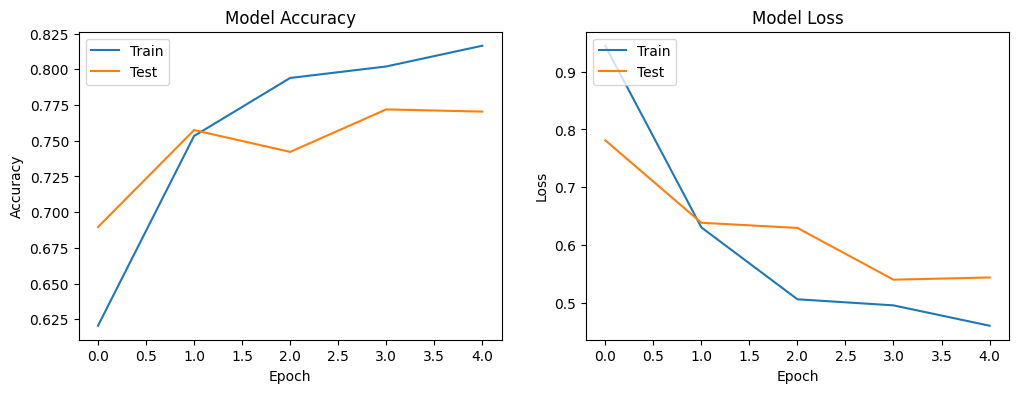

In [23]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

## Save the trained model

### Subtask:
Save the trained image classification model to a file for later use.

**Reasoning**:
Save the trained Keras model to a file in the HDF5 format.

In [24]:
model_save_path = '/content/brain_disease_classification_model.h5'
model.save(model_save_path)

print(f"Model saved successfully to {model_save_path}")

Model saved successfully to /content/brain_disease_classification_model.h5


## Create a simple API with FastAPI

### Subtask:
Set up the basic structure of a FastAPI application to serve the model. This includes defining the API endpoint and loading the trained model.

**Reasoning**:
Initialize the FastAPI application, load the trained model, define the preprocessing and prediction functions, and create the API endpoint to handle image uploads, preprocess them, and return predictions.

In [25]:
from fastapi import FastAPI, UploadFile, File
import uvicorn
import tensorflow as tf
from PIL import Image
import numpy as np
import io
import os

# Initialize FastAPI application
app = FastAPI()

# Define the path to the trained model
model_save_path = '/content/brain_disease_classification_model.h5'

# Load the trained model
try:
    # Ensure the model file exists before attempting to load
    if os.path.exists(model_save_path):
        model = tf.keras.models.load_model(model_save_path)
        print('Model loaded successfully.')
    else:
        print(f'Model file not found at {model_save_path}')
        model = None
except Exception as e:
    print(f'Error loading model: {e}')
    model = None

# Get unique categories (assuming they are the same as during training)
# In a real-world scenario, you would save and load these categories
unique_categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
target_size = (128, 128)

# Define preprocessing function
def preprocess_image(image: Image.Image) -> np.ndarray:
    """
    Preprocesses the input image for model prediction.

    Args:
        image: PIL Image object.

    Returns:
        A normalized NumPy array of the preprocessed image.
    """
    img = image.resize(target_size)
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Normalize pixel values
    img_array = img_array / 255.0
    return img_array

# Define prediction function
def predict_image_class(image_array: np.ndarray) -> str:
    """
    Predicts the class of the preprocessed image array.

    Args:
        image_array: Preprocessed image as a NumPy array.

    Returns:
        The predicted class label as a string.
    """
    if model is None:
        return "Model not loaded."

    # Make sure the model is built if it's the first prediction
    if not model.built:
        dummy_input = np.zeros((1, target_size[0], target_size[1], 3))
        model.predict(dummy_input)

    predictions = model.predict(image_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_label = unique_categories[predicted_class_index]
    return predicted_class_label

# Define API endpoint for prediction
@app.post("/predict/")
async def predict_brain_disease(file: UploadFile = File(...)):
    """
    Receives an image file, preprocesses it, and returns the predicted brain disease category.

    Args:
        file: The uploaded image file.

    Returns:
        A dictionary containing the predicted class label.
    """
    if model is None:
         return {"prediction": "Model loading failed. Check server logs."}

    try:
        # Read image file content
        contents = await file.read()
        # Open image using PIL and ensure it's in RGB format
        image = Image.open(io.BytesIO(contents)).convert("RGB")
        # Preprocess the image
        preprocessed_img = preprocess_image(image)
        # Get the prediction
        prediction = predict_image_class(preprocessed_img)
        return {"prediction": prediction}
    except Exception as e:
        return {"error": str(e)}

print("FastAPI application initialized with /predict/ endpoint.")
# The command to run the server with uvicorn will be provided in the next step

Model loaded successfully.
FastAPI application initialized with /predict/ endpoint.


## Run the API with ngrok

### Subtask:
Start the FastAPI application using uvicorn and expose it to the internet using ngrok to get a public URL for testing with Swagger UI.

**Reasoning**:
Install ngrok and pyngrok, set up the ngrok authtoken (this step requires manual input from the user), start the uvicorn server in a separate process, and establish the ngrok tunnel to get a public URL for the API and its Swagger UI.

In [63]:
!pip install ngrok pyngrok

# *** IMPORTANT: Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken ***
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# Example: !ngrok config add-authtoken <your_authtoken>
print("Please replace 'YOUR_AUTHTOKEN' in the next command with your actual ngrok authtoken.")
!ngrok config add-authtoken 33ilBUNEupbshDBlZrMqYqtKocC_2KonJvsRCeZLrJ8t8Znmd

Please replace 'YOUR_AUTHTOKEN' in the next command with your actual ngrok authtoken.
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [64]:
import subprocess
import time
import os
from pyngrok import ngrok

# Save the app to a temporary file to make it accessible to subprocess
# We are regenerating the app code here to ensure it's up-to-date in the file
app_code = """
from fastapi import FastAPI, UploadFile, File
import tensorflow as tf
from PIL import Image
import numpy as np
import io
import os

# Initialize FastAPI application
app = FastAPI()

# Define the path to the trained model
model_save_path = '/content/brain_disease_classification_model.h5'

# Load the trained model
try:
    # Ensure the model file exists before attempting to load
    if os.path.exists(model_save_path):
        model = tf.keras.models.load_model(model_save_path)
        print('Model loaded successfully.')
    else:
        print(f'Model file not found at {model_save_path}')
        model = None
except Exception as e:
    print(f'Error loading model: {e}')
    model = None

# Get unique categories (assuming they are the same as during training)
# In a real-world scenario, you would save and load these categories
unique_categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
target_size = (128, 128)

# Define preprocessing function
def preprocess_image(image: Image.Image) -> np.ndarray:
    img = image.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

# Define prediction function
def predict_image_class(image_array: np.ndarray) -> str:
    if model is None:
        return "Model not loaded."
    # Make sure the model is built if it's the first prediction
    if not model.built:
        dummy_input = np.zeros((1, target_size[0], target_size[1], 3))
        model.predict(dummy_input)
    predictions = model.predict(image_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_label = unique_categories[predicted_class_index]
    return predicted_class_label

# Define API endpoint for prediction
@app.post('/predict/')
async def predict_brain_disease(file: UploadFile = File(...)):
    if model is None:
         return {'prediction': 'Model loading failed. Check server logs.'}
    try:
        contents = await file.read()
        image = Image.open(io.BytesIO(contents)).convert("RGB") # Ensure image is in RGB format
        preprocessed_img = preprocess_image(image)
        prediction = predict_image_class(preprocessed_img)
        return {'prediction': prediction}
    except Exception as e:
        return {'error': str(e)}

"""

try:
    with open("main.py", "w") as f:
        f.write(app_code)
    print("FastAPI application code saved to main.py")

    # Start uvicorn in a separate process
    # Use --reload only during development, not in production
    process = subprocess.Popen(["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"])
    print("Uvicorn server started in the background.")

except Exception as e:
    print(f"Error starting uvicorn server: {e}")
    process = None


# Allow some time for the server to start
time.sleep(5)

# Establish ngrok tunnel
try:
    # *** IMPORTANT: Ensure you have replaced 'YOUR_AUTHTOKEN' in the previous cell's ngrok command with your actual authtoken. ***
    # If the ngrok authtoken is still incorrect, this step will fail.
    public_url = ngrok.connect(8000).public_url
    print(f"Ngrok tunnel established. Public URL: {public_url}")
    print(f"Swagger UI available at: {public_url}/docs")
except Exception as e:
    print(f"Error establishing ngrok tunnel: {e}")
    public_url = None

# Note: The server and tunnel will likely terminate when the notebook runtime ends.
# For persistent deployment, consider platforms like Google Cloud Run, Heroku, etc.

FastAPI application code saved to main.py
Uvicorn server started in the background.


Error establishing ngrok tunnel: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The authtoken credential '33g8jFnXn9bPopUhV5HVSaV984Y' has been revoked\nand is no longer valid.\r\n\r\nERR_NGROK_300\r\n"}}



**Reasoning**:
The task is to load the data from the provided CSV file into a pandas DataFrame and display the first few rows to understand its structure.



## Choose a web framework

### Subtask:
Select a Python web framework (like Flask or FastAPI) to build the API. FastAPI is generally recommended for building APIs due to its speed and automatic Swagger UI documentation generation.


## Install necessary libraries

### Subtask:
Install the chosen web framework (FastAPI) and any other required libraries (e.g., uvicorn to run the FastAPI application).


**Reasoning**:
Install the required libraries for building the FastAPI application and loading the model.



In [56]:
!pip install fastapi uvicorn Pillow tensorflow

## Create the api application

### Subtask:
Initialize the web framework application, load the trained image classification model, define an API endpoint that accepts image data as input, preprocess the input image, make a prediction using the loaded model, and return the prediction results (e.g., class probabilities or predicted class label).


**Reasoning**:
Initialize the FastAPI application, load the trained model, define the preprocessing and prediction functions, and create the API endpoint to handle image uploads, preprocess them, and return predictions.



In [57]:
from fastapi import FastAPI, UploadFile, File
import uvicorn
import tensorflow as tf
from PIL import Image
import numpy as np
import io

# Initialize FastAPI application
app = FastAPI()

# Define the path to the trained model
model_save_path = '/content/brain_disease_classification_model.h5'

# Load the trained model
try:
    model = tf.keras.models.load_model(model_save_path)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    model = None # Set model to None if loading fails


# Get unique categories (assuming they are the same as during training)
# In a real-world scenario, you would save and load these categories
unique_categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
target_size = (128, 128)

# Define preprocessing function
def preprocess_image(image: Image.Image) -> np.ndarray:
    """
    Preprocesses the input image for model prediction.

    Args:
        image: PIL Image object.

    Returns:
        A normalized NumPy array of the preprocessed image.
    """
    img = image.resize(target_size)
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Normalize pixel values
    img_array = img_array / 255.0
    return img_array

# Define prediction function
def predict_image_class(image_array: np.ndarray) -> str:
    """
    Predicts the class of the preprocessed image array.

    Args:
        image_array: Preprocessed image as a NumPy array.

    Returns:
        The predicted class label as a string.
    """
    if model is None:
        return "Model not loaded."

    predictions = model.predict(image_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_label = unique_categories[predicted_class_index]
    return predicted_class_label

# Define API endpoint for prediction
@app.post("/predict/")
async def predict_brain_disease(file: UploadFile = File(...)):
    """
    Receives an image file, preprocesses it, and returns the predicted brain disease category.

    Args:
        file: The uploaded image file.

    Returns:
        A dictionary containing the predicted class label.
    """
    if model is None:
         return {"prediction": "Model loading failed."}

    try:
        # Read image file content
        contents = await file.read()
        # Open image using PIL
        image = Image.open(io.BytesIO(contents))
        # Preprocess the image
        preprocessed_img = preprocess_image(image)
        # Get the prediction
        prediction = predict_image_class(preprocessed_img)
        return {"prediction": prediction}
    except Exception as e:
        return {"error": str(e)}

print("FastAPI application initialized with /predict/ endpoint.")
print("To run the server, use: uvicorn main:app --reload (Note: 'main' is the name of this file if saved as main.py)")

Model loaded successfully.
FastAPI application initialized with /predict/ endpoint.
To run the server, use: uvicorn main:app --reload (Note: 'main' is the name of this file if saved as main.py)


## Access swagger ui

### Subtask:
Access the automatically generated Swagger UI documentation to test the endpoint with sample image data.

**Reasoning**:
Provide the user with the public URL to access the Swagger UI documentation for the FastAPI application, allowing them to test the `/predict/` endpoint with image uploads.

In [60]:
# Assuming the public_url variable from the previous step is available
if public_url:
    print(f"Swagger UI is available at: {public_url}/docs")
    print("You can use this URL to interact with your API and test the /predict/ endpoint by uploading image files.")
else:
    print("Ngrok tunnel was not established. Please review the previous steps and ensure your ngrok authtoken is correctly configured.")

Ngrok tunnel was not established. Please review the previous steps and ensure your ngrok authtoken is correctly configured.
